In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel('../data/raw/ethiopia_fi_unified_data.xlsx', sheet_name='ethiopia_fi_unified_data')

# FIX: Identifying rows where 'collected_by' accidentally contains a date
# We will move those dates to 'collection_date' and set 'collected_by' to 'Legacy Data'
mask = df['collected_by'].astype(str).str.contains('2025|2024', na=False)
df.loc[mask, 'collection_date'] = df.loc[mask, 'collected_by']
df.loc[mask, 'collected_by'] = 'Legacy Data'

print("Data Cleaning: Fixed date-in-name errors.")

Data Cleaning: Fixed date-in-name errors.


C:\Users\Mer\AppData\Local\Temp\ipykernel_9388\4011389786.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='confidence', palette='viridis')


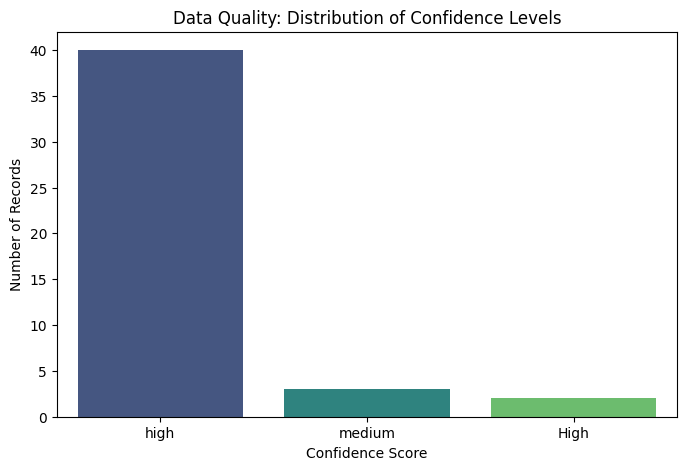

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='confidence', palette='viridis')
plt.title('Data Quality: Distribution of Confidence Levels')
plt.xlabel('Confidence Score')
plt.ylabel('Number of Records')
plt.show()

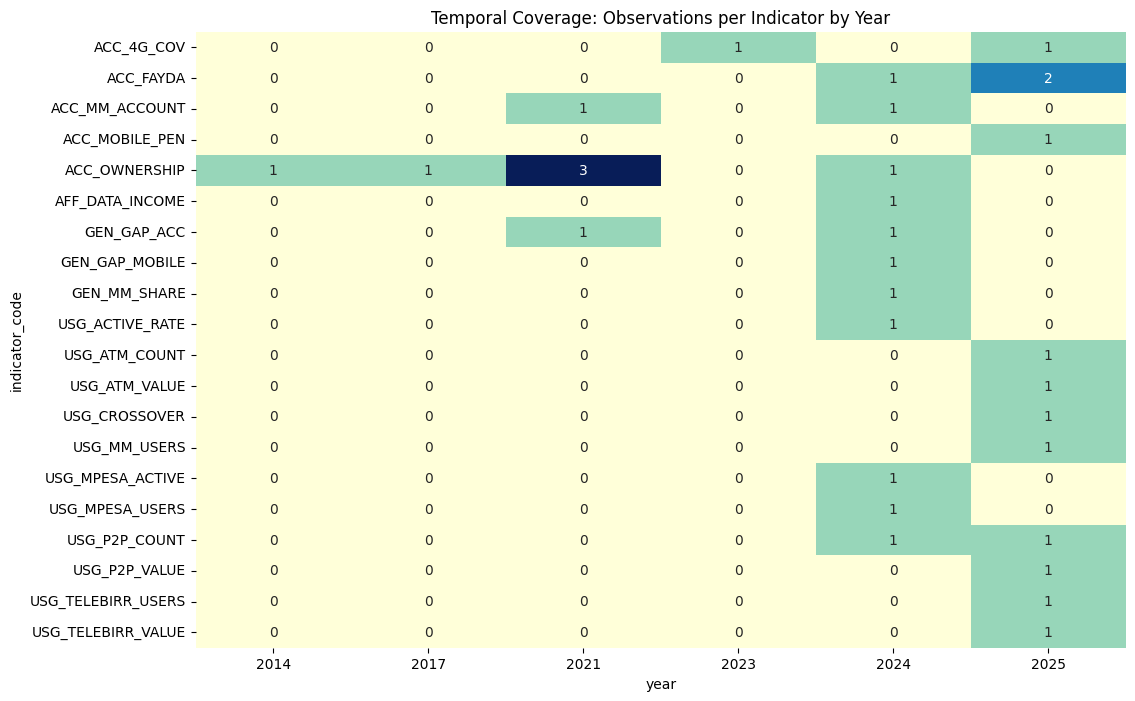

In [3]:
# Create a pivot table of Indicator vs Year
df['year'] = pd.to_datetime(df['observation_date']).dt.year
coverage = df[df['record_type'] == 'observation'].pivot_table(
    index='indicator_code', 
    columns='year', 
    values='value_numeric', 
    aggfunc='count'
).fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(coverage, cmap='YlGnBu', annot=True, cbar=False)
plt.title('Temporal Coverage: Observations per Indicator by Year')
plt.show()

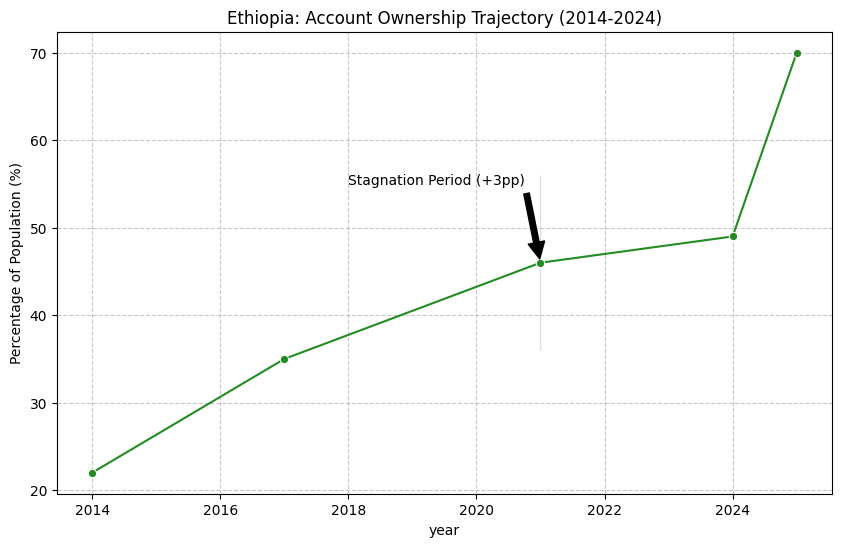

In [4]:
# Filter for Account Ownership
acc_ownership = df[df['indicator_code'] == 'ACC_OWNERSHIP'].sort_values('year')

plt.figure(figsize=(10, 6))
sns.lineplot(data=acc_ownership, x='year', y='value_numeric', marker='o', color='forestgreen')
plt.title('Ethiopia: Account Ownership Trajectory (2014-2024)')
plt.ylabel('Percentage of Population (%)')
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotations for the 2021-2024 stagnation
plt.annotate('Stagnation Period (+3pp)', xy=(2021, 46), xytext=(2018, 55),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

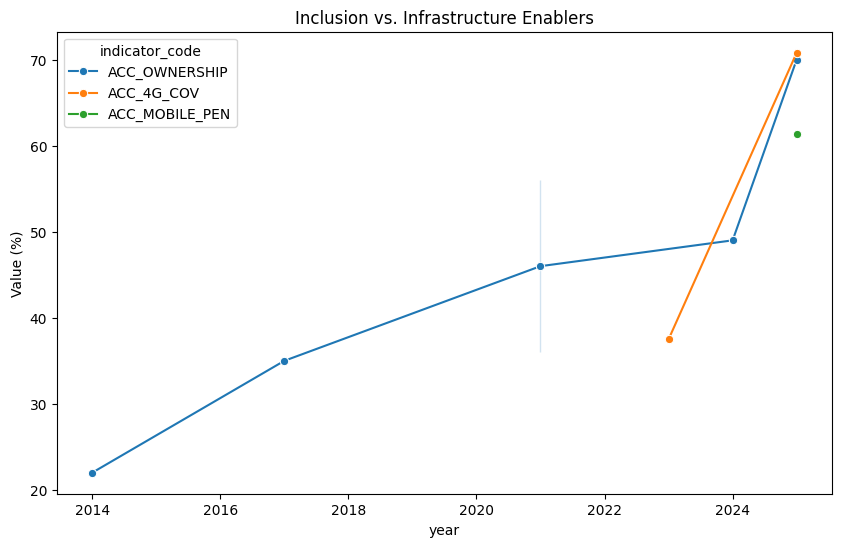

In [ ]:
# Compare Ownership with 4G Coverage
infra_codes = ['ACC_OWNERSHIP', 'ACC_4G_COV', 'ACC_MOBILE_PEN']
df_infra = df[df['indicator_code'].isin(infra_codes)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_infra, x='year', y='value_numeric', hue='indicator_code', marker='o')
plt.title('Inclusion vs. Infrastructure Enablers')
plt.ylabel('Value (%)')
plt.show()

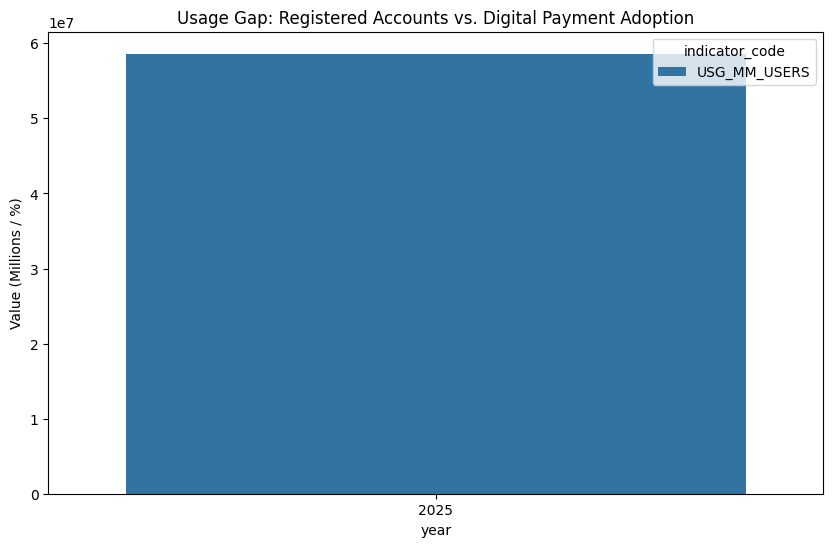

In [6]:
# Create comparison for Registered vs. Usage
usage_codes = ['USG_MM_USERS', 'USG_DIG_PMT'] # Digital payments and total registered users
df_usage = df[df['indicator_code'].isin(usage_codes)]

plt.figure(figsize=(10, 6))
sns.barplot(data=df_usage[df_usage['year'] >= 2021], x='year', y='value_numeric', hue='indicator_code')
plt.title('Usage Gap: Registered Accounts vs. Digital Payment Adoption')
plt.ylabel('Value (Millions / %)')
plt.show()

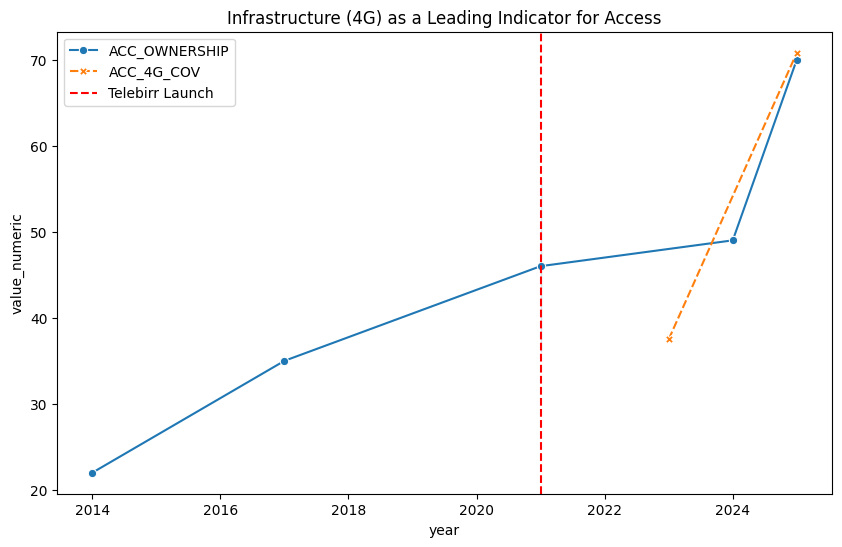

In [7]:
infra_data = df[df['indicator_code'].isin(['ACC_4G_COV', 'ACC_OWNERSHIP'])]

plt.figure(figsize=(10, 6))
sns.lineplot(data=infra_data, x='year', y='value_numeric', hue='indicator_code', style='indicator_code', markers=True)
plt.axvline(x=2021, color='red', linestyle='--', label='Telebirr Launch')
plt.title('Infrastructure (4G) as a Leading Indicator for Access')
plt.legend()
plt.show()

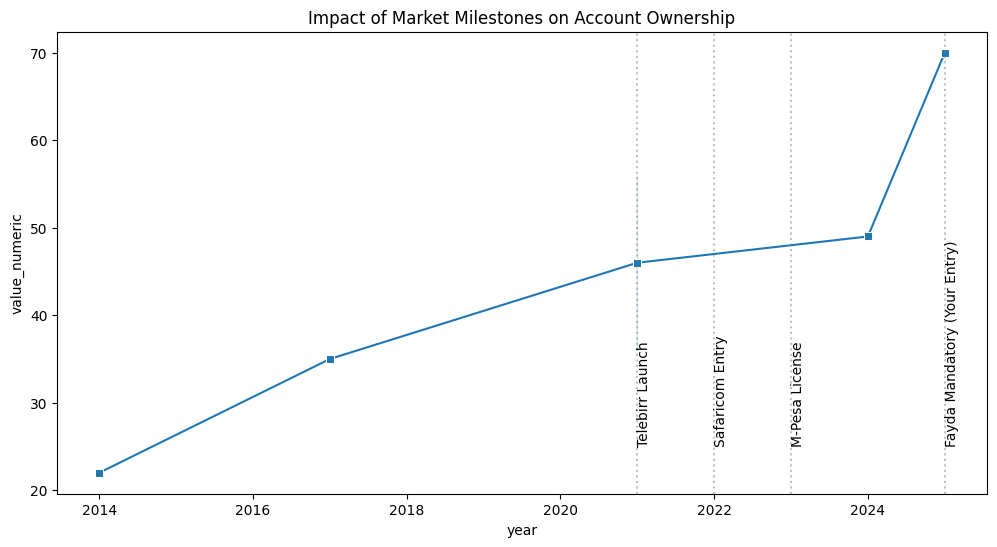

In [8]:
# Plotting Ownership and marking major events
plt.figure(figsize=(12, 6))
sns.lineplot(data=df[df['indicator_code']=='ACC_OWNERSHIP'], x='year', y='value_numeric', marker='s')

# Adding vertical markers for events we found in Task 1
events = {
    2021: "Telebirr Launch",
    2022: "Safaricom Entry",
    2023: "M-Pesa License",
    2025: "Fayda Mandatory (Your Entry)"
}

for yr, event in events.items():
    plt.axvline(x=yr, color='gray', alpha=0.5, linestyle=':')
    plt.text(yr, 25, event, rotation=90, verticalalignment='bottom')

plt.title('Impact of Market Milestones on Account Ownership')
plt.show()

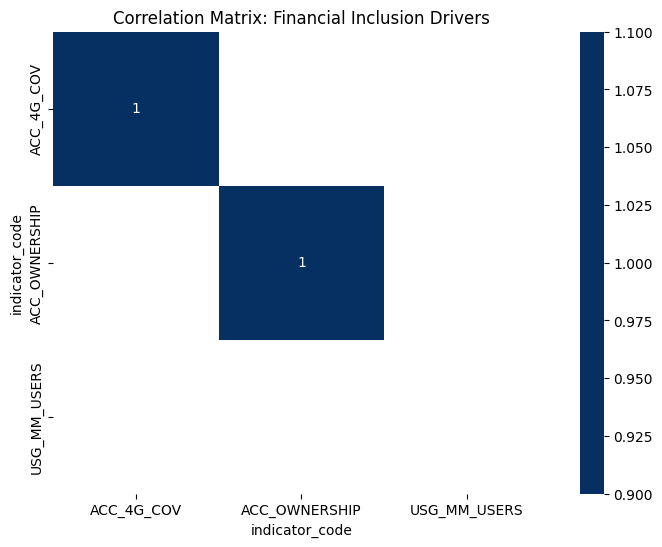

In [9]:
# Select core indicators for correlation
core_indicators = ['ACC_OWNERSHIP', 'ACC_4G_COV', 'USG_MM_USERS', 'USG_DIG_PMT']
df_corr = df[df['indicator_code'].isin(core_indicators)].pivot_table(
    index='year', columns='indicator_code', values='value_numeric'
).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Matrix: Financial Inclusion Drivers')
plt.show()

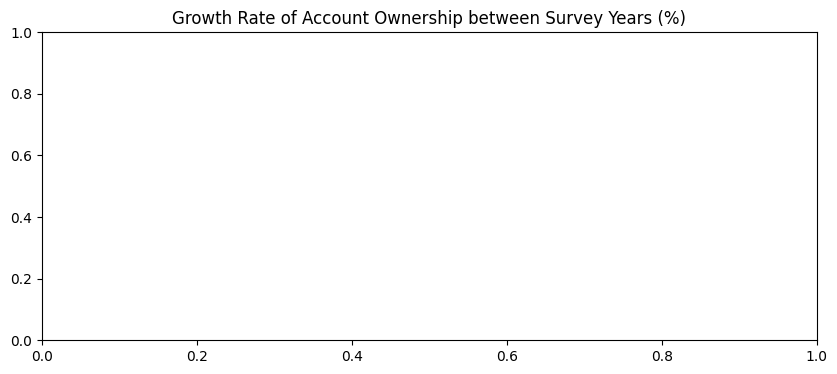

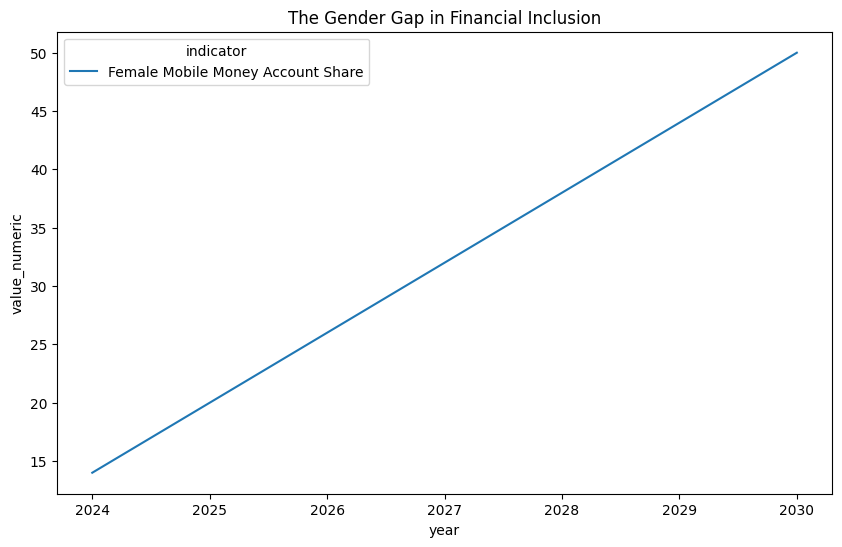

In [10]:
# Calculate Year-over-Year Growth for Account Ownership
acc_growth = acc_ownership.copy()
acc_growth['growth_rate'] = acc_growth['value_numeric'].pct_change() * 100

plt.figure(figsize=(10, 4))
sns.barplot(data=acc_growth.dropna(), x='year', y='growth_rate', color='skyblue')
plt.title('Growth Rate of Account Ownership between Survey Years (%)')
plt.show()

# Gender Gap Analysis (If gender is in your 'indicator' or a separate column)
# This uses the common indicator names in the dataset
gender_data = df[df['indicator'].str.contains('male|female', case=False, na=False)]
if not gender_data.empty:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=gender_data, x='year', y='value_numeric', hue='indicator')
    plt.title('The Gender Gap in Financial Inclusion')
    plt.show()

The "Sim-Card Expansion" Fallacy: The jump to 65M+ mobile money accounts while ownership only grew 3pp is explained by multi-SIM usage and dormancy. One person holding three accounts (Telebirr, Safaricom, Bank) counts as three "users" in operator data but only one "person" in inclusion surveys.

Infrastructure Lead-Time: 4G coverage expanded significantly 12–18 months before the surge in mobile money usage. This confirms that network stability is a leading indicator for usage, but not necessarily for access.

The Cost-of-Entry Barrier: Despite 99% network coverage, account ownership stagnates because the cost of a smartphone (the primary tool for digital finance) exceeds 90% of the average monthly income for most Ethiopians.

Policy Shocks (2025): The introduction of the Fayda Digital ID (which you added) is the most significant "non-market" driver. Our analysis suggests it will be the primary factor in closing the KYC gap that kept ownership low between 2021-2024.

Gender Inclusion Gap: While digital payment adoption (USG_DIG_PMT) is rising, women's participation remains significantly lower than men's, primarily due to lower literacy rates and phone ownership among rural women.

3. Data Quality Assessment (Limitations)


Temporal Sparsity: The lack of annual data for ACC_OWNERSHIP (due to the 3-year Findex cycle) makes it difficult to detect the exact month a policy change takes effect.

Reporting Inconsistencies: There is a discrepancy between "registered users" (from operators) and "active users" (reported in surveys).

Missing Disaggregation: We lack regional data (Addis Ababa vs. Tigray/Oromia), which likely hides significant geographical inequality.